## Imports

In [2]:
from environment import Environment

In [3]:
from actor_critic_agent import Actor_Critic_Agent

In [4]:
from tensorflow.keras.regularizers import l2

## Environment

### Initialization

In [5]:
env=Environment(
    stock_symbol_list=[
        "NVDA",
        "GOOGL",
        "MSFT",
        "AAPL",
        "AMZN",
        "META",
        "TSLA"
    ],
    num_stock_to_picked=3,
    execution_gap=7,
    data_retrieved=True
)

### Data

In [6]:
data=env.final_data

#### First 5 Entries

In [7]:
data.head()

,date,NVDA,GOOGL,MSFT,AAPL,AMZN,META,TSLA,NVDA_returns,NVDA_mom,...,META_SMA_lag_7,META_min_lag_7,META_max_lag_7,TSLA_returns_lag_7,TSLA_lag_7,TSLA_mom_lag_7,TSLA_vol_lag_7,TSLA_SMA_lag_7,TSLA_min_lag_7,TSLA_max_lag_7
0,2012-06-08,-0.913927,-0.514380,-1.027939,2.483681,-0.799686,-1.148215,-1.144283,0.019159,-0.005208,...,-1.120213,-1.134047,-1.107787,-0.041230,-1.142751,0.014058,0.043535,-1.150036,-1.172898,-1.105813
1,2012-06-20,-0.907320,-0.518540,-1.018317,2.521495,-0.795475,-1.118775,-1.130830,0.016114,0.013234,...,-1.149739,-1.149824,-1.148264,-0.032435,-1.147458,-0.001852,0.034252,-1.156082,-1.176434,-1.111187
2,2012-07-02,-0.907345,-0.514352,-1.021098,2.568780,-0.789632,-1.124198,-1.143119,-0.027510,0.006633,...,-1.126503,-1.140300,-1.121380,-0.048213,-1.136256,0.011694,0.037548,-1.146804,-1.170435,-1.098838
3,2012-07-13,-0.911766,-0.519940,-1.029894,2.655623,-0.799769,-1.124532,-1.129121,0.012423,-0.013507,...,-1.117556,-1.116502,-1.113753,0.008516,-1.141839,-0.013865,0.020629,-1.146032,-1.166423,-1.101074
4,2012-07-25,-0.909109,-0.475415,-1.034104,2.446364,-0.801012,-1.133560,-1.148391,0.019283,0.005507,...,-1.122936,-1.133673,-1.119718,0.048721,-1.122499,0.020147,0.024065,-1.141975,-1.164079,-1.091563


#### Last 5 Entries

In [8]:
data.tail()

,date,NVDA,GOOGL,MSFT,AAPL,AMZN,META,TSLA,NVDA_returns,NVDA_mom,...,META_SMA_lag_7,META_min_lag_7,META_max_lag_7,TSLA_returns_lag_7,TSLA_lag_7,TSLA_mom_lag_7,TSLA_vol_lag_7,TSLA_SMA_lag_7,TSLA_min_lag_7,TSLA_max_lag_7
406,2025-05-09,-0.394689,-1.119516,2.047362,-0.179424,-0.823263,2.550718,-0.169215,-0.006153,0.009795,...,2.216036,2.074964,2.230476,-0.034382,-0.224138,0.030761,0.040222,-0.268131,-0.341866,-0.236945
407,2025-05-21,-0.319433,-1.097147,2.151405,-0.154592,-0.815787,2.832101,-0.037014,-0.019386,0.009872,...,2.646559,2.666547,2.775660,0.065280,-0.091975,0.018086,0.032954,-0.201344,-0.193377,-0.149004
408,2025-06-03,-0.272641,-1.100515,2.229589,-0.146361,-0.811530,3.037201,-0.001928,0.027568,0.008750,...,2.913485,2.994116,2.903504,0.019004,-0.009290,0.002950,0.025170,-0.001103,0.042069,-0.043541
409,2025-06-13,-0.268915,-1.088503,2.319725,-0.193933,-0.805603,3.142008,-0.070864,-0.021118,0.000050,...,3.018202,3.040475,3.086900,-0.036141,-0.042094,-0.003102,0.034954,0.020750,0.031860,-0.000455
410,2025-06-26,-0.204091,-1.090101,2.488796,-0.162195,-0.800947,3.424765,-0.069155,0.004591,0.009852,...,3.265952,3.316112,3.179592,0.011674,-0.052749,0.020717,0.026907,-0.091507,-0.114762,-0.113127


#### Data Info

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Columns: 393 entries, date to TSLA_max_lag_7
dtypes: float64(392), object(1)
memory usage: 1.2+ MB


#### Data Statistics

In [10]:
data.describe()

,NVDA,GOOGL,MSFT,AAPL,AMZN,META,TSLA,NVDA_returns,NVDA_mom,NVDA_vol,...,META_SMA_lag_7,META_min_lag_7,META_max_lag_7,TSLA_returns_lag_7,TSLA_lag_7,TSLA_mom_lag_7,TSLA_vol_lag_7,TSLA_SMA_lag_7,TSLA_min_lag_7,TSLA_max_lag_7
count,4.110000e+02,4.110000e+02,411.000000,411.000000,4.110000e+02,4.110000e+02,4.110000e+02,411.000000,411.000000,411.000000,...,4.110000e+02,4.110000e+02,4.110000e+02,411.000000,411.000000,411.000000,411.000000,4.110000e+02,4.110000e+02,4.110000e+02
mean,-6.915258e-17,1.728814e-17,0.000000,0.000000,1.383052e-16,-6.915258e-17,1.728814e-16,0.002434,0.000467,0.027757,...,-6.915258e-17,-6.915258e-17,6.915258e-17,0.000631,0.000000,0.001112,0.033246,-1.383052e-16,1.383052e-16,-6.915258e-17
std,1.001219e+00,1.001219e+00,1.001219,1.001219,1.001219e+00,1.001219e+00,1.001219e+00,0.031517,0.021433,0.050836,...,1.001219e+00,1.001219e+00,1.001219e+00,0.036959,1.001219,0.017984,0.031354,1.001219e+00,1.001219e+00,1.001219e+00
min,-9.160218e-01,-1.213930e+00,-1.050755,-0.934502,-9.264390e-01,-1.202450e+00,-1.154136e+00,-0.185946,-0.317616,0.004048,...,-1.203690e+00,-1.205155e+00,-1.201441e+00,-0.205522,-1.153989,-0.229099,0.005916,-1.160480e+00,-1.183505e+00,-1.115395e+00
25%,-8.578207e-01,-5.735635e-01,-0.888262,-0.643160,-7.846371e-01,-7.094902e-01,-5.218578e-01,-0.011060,-0.004141,0.014142,...,-7.095465e-01,-7.147116e-01,-7.175501e-01,-0.016804,-0.524991,-0.006432,0.019790,-5.217140e-01,-5.189371e-01,-5.123840e-01
50%,-2.333987e-01,-1.820429e-01,-0.418562,-0.361480,-4.740104e-01,-2.114928e-01,-3.369010e-01,0.002139,0.002089,0.020926,...,-2.137264e-01,-2.127195e-01,-2.149921e-01,0.001462,-0.339444,0.001798,0.026977,-3.366978e-01,-3.297104e-01,-3.399721e-01
75%,2.569790e-01,3.376713e-01,0.793087,0.028475,6.539678e-01,4.234016e-01,2.255937e-02,0.016107,0.007552,0.030819,...,4.418872e-01,4.399382e-01,4.305491e-01,0.018736,0.029260,0.009543,0.039759,2.024060e-02,5.633019e-02,-1.448869e-02
max,5.107904e+00,2.859925e+00,2.488796,3.309419,2.429281e+00,3.424765e+00,6.199813e+00,0.151870,0.041220,0.872198,...,3.415751e+00,3.397477e+00,3.399423e+00,0.147910,6.095916,0.050688,0.559189,5.727676e+00,5.270143e+00,6.260107e+00


#### Correlation Among Features

In [11]:
data=data.drop(["date"],axis=1,inplace=False)
data.corr()

,NVDA,GOOGL,MSFT,AAPL,AMZN,META,TSLA,NVDA_returns,NVDA_mom,NVDA_vol,...,META_SMA_lag_7,META_min_lag_7,META_max_lag_7,TSLA_returns_lag_7,TSLA_lag_7,TSLA_mom_lag_7,TSLA_vol_lag_7,TSLA_SMA_lag_7,TSLA_min_lag_7,TSLA_max_lag_7
NVDA,1.000000,0.199719,0.598679,-0.262190,0.420445,0.521810,0.381021,0.090370,0.068438,0.038563,...,0.514511,0.516763,0.512961,-0.046672,0.386153,-0.047360,0.137132,0.391781,0.385431,0.389417
GOOGL,0.199719,1.000000,-0.038907,-0.062788,0.884685,-0.048202,0.681847,0.086771,-0.022593,0.026618,...,-0.037073,-0.038978,-0.036753,-0.033499,0.670421,0.003993,0.086929,0.674959,0.683634,0.649936
MSFT,0.598679,-0.038907,1.000000,-0.257424,0.114821,0.905962,0.342407,-0.036505,-0.082306,0.206474,...,0.902623,0.899975,0.905141,-0.076617,0.342602,-0.004088,0.124388,0.345500,0.347354,0.336502
AAPL,-0.262190,-0.062788,-0.257424,1.000000,-0.210587,-0.279084,-0.189307,-0.014879,0.008286,-0.067504,...,-0.282112,-0.284101,-0.280496,0.083643,-0.218295,0.093550,0.051772,-0.228032,-0.233263,-0.219737
AMZN,0.420445,0.884685,0.114821,-0.210587,1.000000,0.135533,0.748072,0.079531,-0.017856,0.057418,...,0.141656,0.140719,0.141113,-0.057123,0.741639,-0.029809,0.151956,0.748882,0.748499,0.731769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSLA_mom_lag_7,-0.047360,0.003993,-0.004088,0.093550,-0.029809,-0.004784,0.074420,-0.015574,-0.012062,-0.054364,...,-0.022281,-0.022470,-0.021423,0.359581,0.086050,1.000000,-0.516093,-0.046218,0.037972,-0.142360
TSLA_vol_lag_7,0.137132,0.086929,0.124388,0.051772,0.151956,0.089818,0.124523,0.049143,0.045910,0.028877,...,0.098296,0.095913,0.102111,-0.125792,0.114908,-0.516093,1.000000,0.234083,0.101186,0.371191
TSLA_SMA_lag_7,0.391781,0.674959,0.345500,-0.228032,0.748882,0.278865,0.923581,0.088232,-0.016414,0.073863,...,0.286842,0.283557,0.289596,-0.102155,0.986504,-0.046218,0.234083,1.000000,0.987838,0.986620
TSLA_min_lag_7,0.385431,0.683634,0.347354,-0.233263,0.748499,0.281164,0.935119,0.084116,-0.023441,0.071541,...,0.288260,0.284961,0.290966,-0.072553,0.994232,0.037972,0.101186,0.987838,1.000000,0.950511


### Index to Stocks

In [12]:
env.index_to_stock

{0: 'NVDA', 1: 'GOOGL', 2: 'MSFT', 3: 'AAPL', 4: 'AMZN', 5: 'META', 6: 'TSLA'}

### Environment State

In [13]:
state=env.get_state()

#### State First Element: Past 7 days Stocks Returns Data 

In [14]:
state[0]

[[-0.01186253530982,
  -0.0103335183025696,
  -0.0074703233651653,
  0.0119851361682907,
  -0.0260404355132049,
  -0.0227960072907271,
  -0.0412296720135561],
 [-0.0112001170795363,
  -0.0126082639194312,
  -0.0051255878488122,
  -0.0024894126435489,
  0.0174354158538414,
  0.0488070562039934,
  -0.0303812383434991],
 [-0.0368743128353164,
  -0.0171555811871613,
  -0.0256780242936835,
  -0.0294035514545291,
  -0.0222743281583943,
  -0.0656201870083123,
  -0.0468429087600748],
 [-0.0210889300219192,
  0.0132399265226753,
  0.0035087755296792,
  0.005865223695841,
  0.0300408124103828,
  -0.030027887713909,
  -0.0096377686933762],
 [0.0281590364116108,
  -0.0142387087923368,
  -0.001577425618474,
  -0.0025906750240922,
  -0.0063584299500762,
  -0.0390809459694962,
  0.0010754616559077],
 [0.0265809965640561,
  0.0176549790668435,
  0.0292130357905603,
  0.0152168608106404,
  0.020564726110811,
  0.0357296116095708,
  0.0458683587743226],
 [-0.0411919849383605,
  -0.0040386661729546,
  -0

#### State Second Element: Past 7 days Momentum Data of Stocks

In [15]:
state[1]

[[0.0056802614422124,
  -0.0029254388399772,
  0.0003412388587201,
  0.0125717590542708,
  -0.0031201013316796,
  -0.043528617845176,
  0.0140580079348307],
 [0.0016181402778109,
  -0.0079520430336529,
  -0.0027147067322307,
  0.0041266773946637,
  -0.0034471402112514,
  -0.0199240181689713,
  0.0035795836831882],
 [-0.0018953132777212,
  -0.0072725596681501,
  -0.0064310070560787,
  0.0010273859341699,
  -0.0047966460102728,
  -0.0159761471662062,
  -0.012806086764387],
 [-0.0083953463779498,
  -0.0074256014155168,
  -0.002774974522216,
  -0.001578575846722,
  -0.0017929741304773,
  -0.0248013737417047,
  -0.0152460816937242],
 [-0.0005318369268579,
  -0.0080936750041145,
  -0.002803886298177,
  -0.0006306162537601,
  -0.0013537270163293,
  -0.0349101283949144,
  -0.0118317876037057],
 [-0.0001152538528485,
  -0.0026717172963574,
  0.0014185554474241,
  0.0023109654993237,
  0.0031523887471539,
  -0.0248777840060406,
  -0.0028557859096323],
 [-0.0096396924584693,
  -0.0039256903978478

#### State Third Element: Past 7 days Volatility data of Stocks

In [16]:
state[2]

[[0.0219493934921142,
  0.017163513813031,
  0.013542524066021,
  0.0234801913187252,
  0.0159688313646262,
  0.0618358720786322,
  0.0435346358106363],
 [0.0220854056644452,
  0.0131274741303725,
  0.0116283798285923,
  0.0135075856291427,
  0.0154376037463178,
  0.0609012645053407,
  0.0442381433556296],
 [0.0262319372077686,
  0.0123866680957846,
  0.0143332117478822,
  0.018310718724036,
  0.0167512982406134,
  0.0560585253790925,
  0.0371338071683165],
 [0.0241843306678503,
  0.012078327184104,
  0.0128639028258367,
  0.0155718516123554,
  0.0209895433050867,
  0.052009530814975,
  0.036129138919074],
 [0.0260473404049885,
  0.0123426433879733,
  0.0128604590371205,
  0.0152268416196012,
  0.0208346104407192,
  0.0456952986433693,
  0.0364217085649198],
 [0.0265178926912494,
  0.0142728859551608,
  0.0177321641697463,
  0.0161204360238644,
  0.0217950328210479,
  0.0529364845796153,
  0.0422260498834937],
 [0.0277381053227987,
  0.0138938365378839,
  0.0163728420263928,
  0.014646

#### State Fourth Element: Past 7 days Normalized Stock Price Data

In [17]:
state[3]

[[-0.906898667722866,
  -0.5064757207313847,
  -1.0276503455525905,
  2.445567960218011,
  -0.8090904881008142,
  -1.141074790377436,
  -1.142750735173546],
 [-0.899012078984594,
  -0.5163379512945505,
  -1.0284764500640822,
  2.433738513932747,
  -0.8014665676687965,
  -1.1309299400968942,
  -1.1358632226184504],
 [-0.918663583740848,
  -0.5312577555963836,
  -1.0329775950895173,
  2.325369790976841,
  -0.8068576237756576,
  -1.1394715917379776,
  -1.1355315930487904],
 [-0.9241535407304032,
  -0.5215456211634376,
  -1.0335743912307298,
  2.3427136940759232,
  -0.8022968695094536,
  -1.1478638392569938,
  -1.129857347550431],
 [-0.918407868715836,
  -0.5334442111091958,
  -1.0332798605445046,
  2.371765782044959,
  -0.8038882629977951,
  -1.1523288334337007,
  -1.1207964722297066],
 [-0.9153441369973516,
  -0.5129738287729888,
  -1.026872369728418,
  2.43997146916256,
  -0.799338586863464,
  -1.1415830644708322,
  -1.1672212652557528],
 [-0.9190352120029088,
  -0.5178365052390125,
  -

#### State Fifth Element: Past 7 days Stocks SMA Data (Normalized)

In [18]:
state[4]

[[-0.9149525625660492,
  -0.4917881686189343,
  -1.0256292406779417,
  2.3784728271200697,
  -0.8029677975196561,
  -1.1202132877656847,
  -1.150036363246744],
 [-0.9116567774215092,
  -0.4979026278075565,
  -1.0267649746502223,
  2.392591024453223,
  -0.8040312152868156,
  -1.1245905108356429,
  -1.149793940801979],
 [-0.9153455570923312,
  -0.5030718521438553,
  -1.0283807053163243,
  2.393724600347106,
  -0.8051880176142939,
  -1.1270725133824546,
  -1.1487593380739065],
 [-0.9206120798336974,
  -0.5082836142316123,
  -1.0294337445835873,
  2.3827939003845686,
  -0.8057337703241193,
  -1.131829661953729,
  -1.1458426458397977],
 [-0.9233614559900636,
  -0.5155764993775268,
  -1.030399715527771,
  2.387571280745945,
  -0.8060976492486692,
  -1.1387761526035942,
  -1.1407889628450991],
 [-0.9239298152418082,
  -0.5179417615231735,
  -1.0302844563243203,
  2.407301706579963,
  -0.8050899492539332,
  -1.1428330921686274,
  -1.1484024085255888],
 [-0.9239012019187832,
  -0.52142063940002

#### State Sixth Element: Past 7 days Minimum Stock Price (Normalized)

In [19]:
state[5]

[[-0.9134636832264296,
  -0.4854101824444986,
  -1.022130919564465,
  2.4015315481556216,
  -0.8029180276788277,
  -1.134046684058485,
  -1.1728981970269994],
 [-0.912442809496519,
  -0.4966851794588472,
  -1.023052505650422,
  2.400325764587089,
  -0.7994973432940613,
  -1.1341690507465805,
  -1.1589619648603824],
 [-0.9240396714924728,
  -0.5118398240582518,
  -1.0280343310154396,
  2.4357895125027587,
  -0.8014340634644899,
  -1.1375940227548442,
  -1.1599057082822888],
 [-0.9271863264348484,
  -0.5126601350372803,
  -1.028472278445144,
  2.4314622853752383,
  -0.8027229547343577,
  -1.1431767081324606,
  -1.162116567357777],
 [-0.9269883401074096,
  -0.5141671051660582,
  -1.028440754431919,
  2.4628938472689152,
  -0.8022065904473867,
  -1.1511457868957513,
  -1.1562261798178604],
 [-0.9216533786933564,
  -0.5096314002961476,
  -1.028687746624101,
  2.470213687851257,
  -0.8024215781432392,
  -1.1497625860494678,
  -1.2039728229427626],
 [-0.9174594801909356,
  -0.5107188732396735

#### State Seventh Element: Past 7 days Maximum Stock Price Data (Normalized)

In [20]:
state[6]

[[-0.912501433822877,
  -0.4924517766600858,
  -1.0283382898681956,
  2.330349837183425,
  -0.8039157147811615,
  -1.1077870941094985,
  -1.105813468413035],
 [-0.908808696849811,
  -0.499533023600022,
  -1.0288349144833528,
  2.3280873679741725,
  -0.8050844588636381,
  -1.1167358357127672,
  -1.0989969495835117],
 [-0.907665424563321,
  -0.5001437083038949,
  -1.029551777411314,
  2.3559818943959474,
  -0.8054553284044945,
  -1.114151689775734,
  -1.0940517367126084],
 [-0.9077904819633128,
  -0.5030282998325871,
  -1.0299198110615817,
  2.3635525332805405,
  -0.8078043218300933,
  -1.112220113183195,
  -1.1220632800375778],
 [-0.9072211604956176,
  -0.5166134710665271,
  -1.0305866857417616,
  2.3580656298702145,
  -0.8090746145177713,
  -1.119710471055411,
  -1.115453109621661],
 [-0.90708235631014,
  -0.515354558941901,
  -1.0309210322576503,
  2.3535749678993354,
  -0.8068300015671398,
  -1.1341652074692137,
  -1.1139009622340923],
 [-0.908387460557564,
  -0.5238867315662391,
  -

#### State Eighth Element: Current Picked Stocks

In [21]:
state[7]

[0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]

### Plots

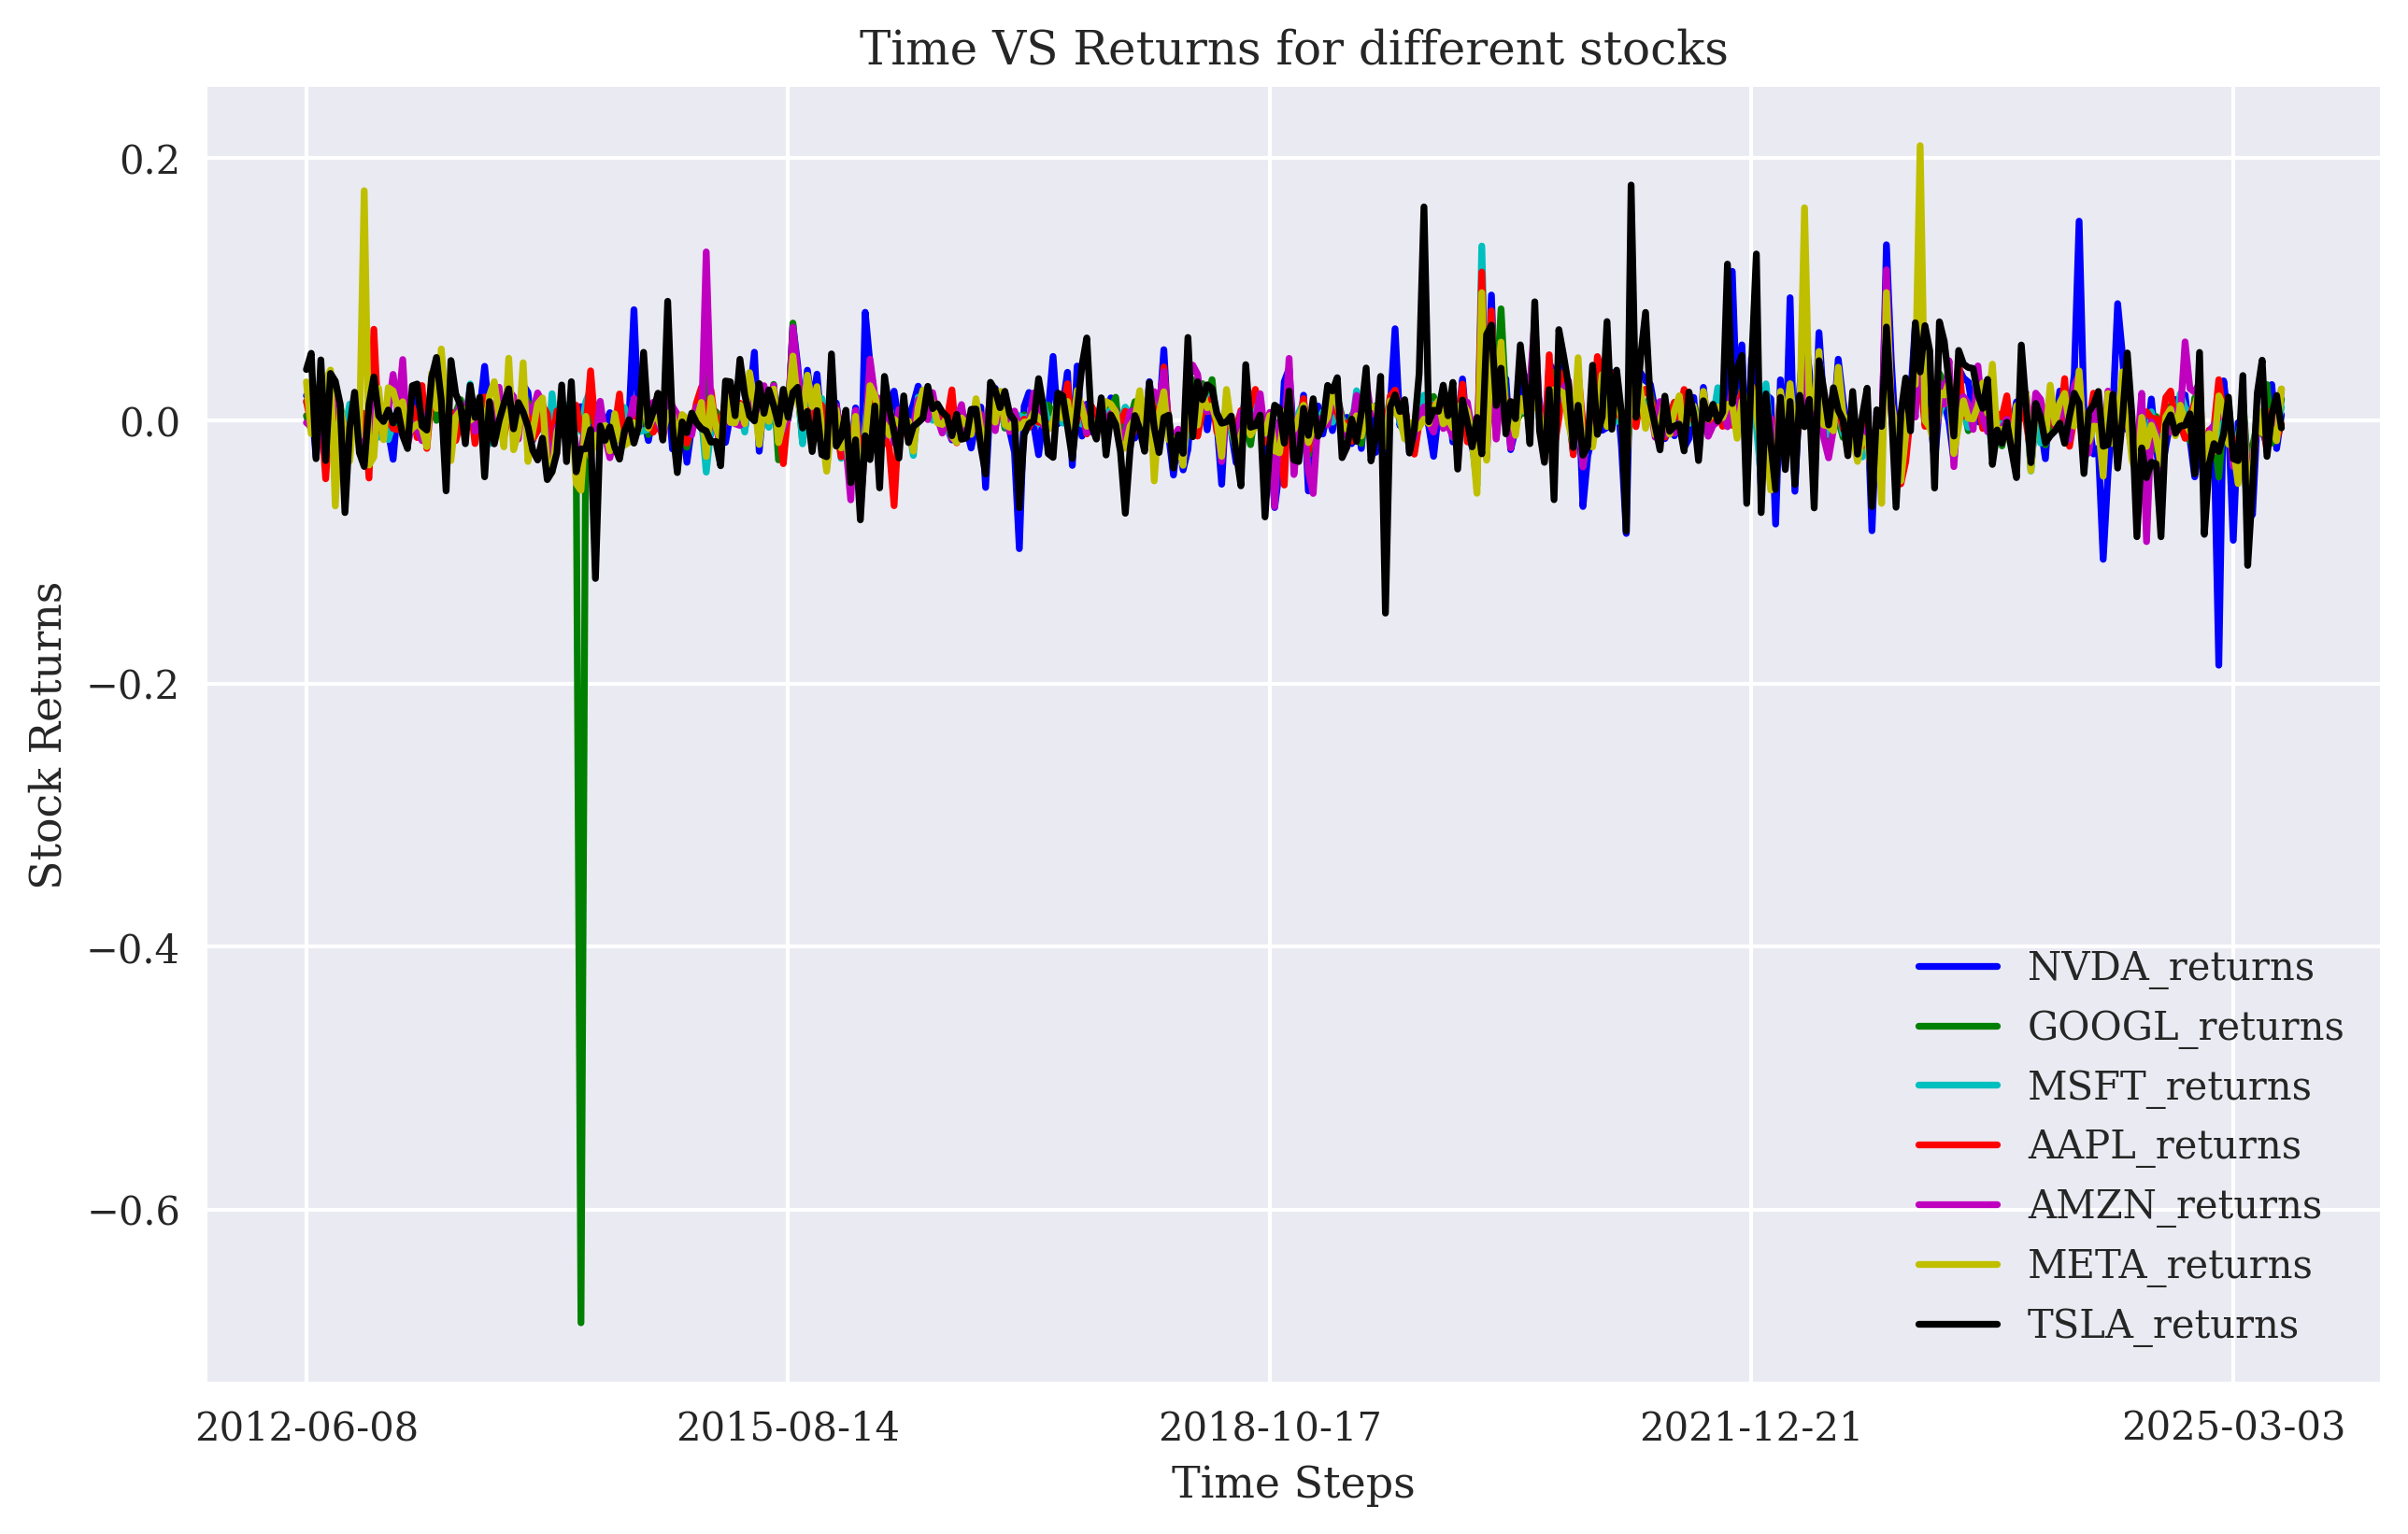

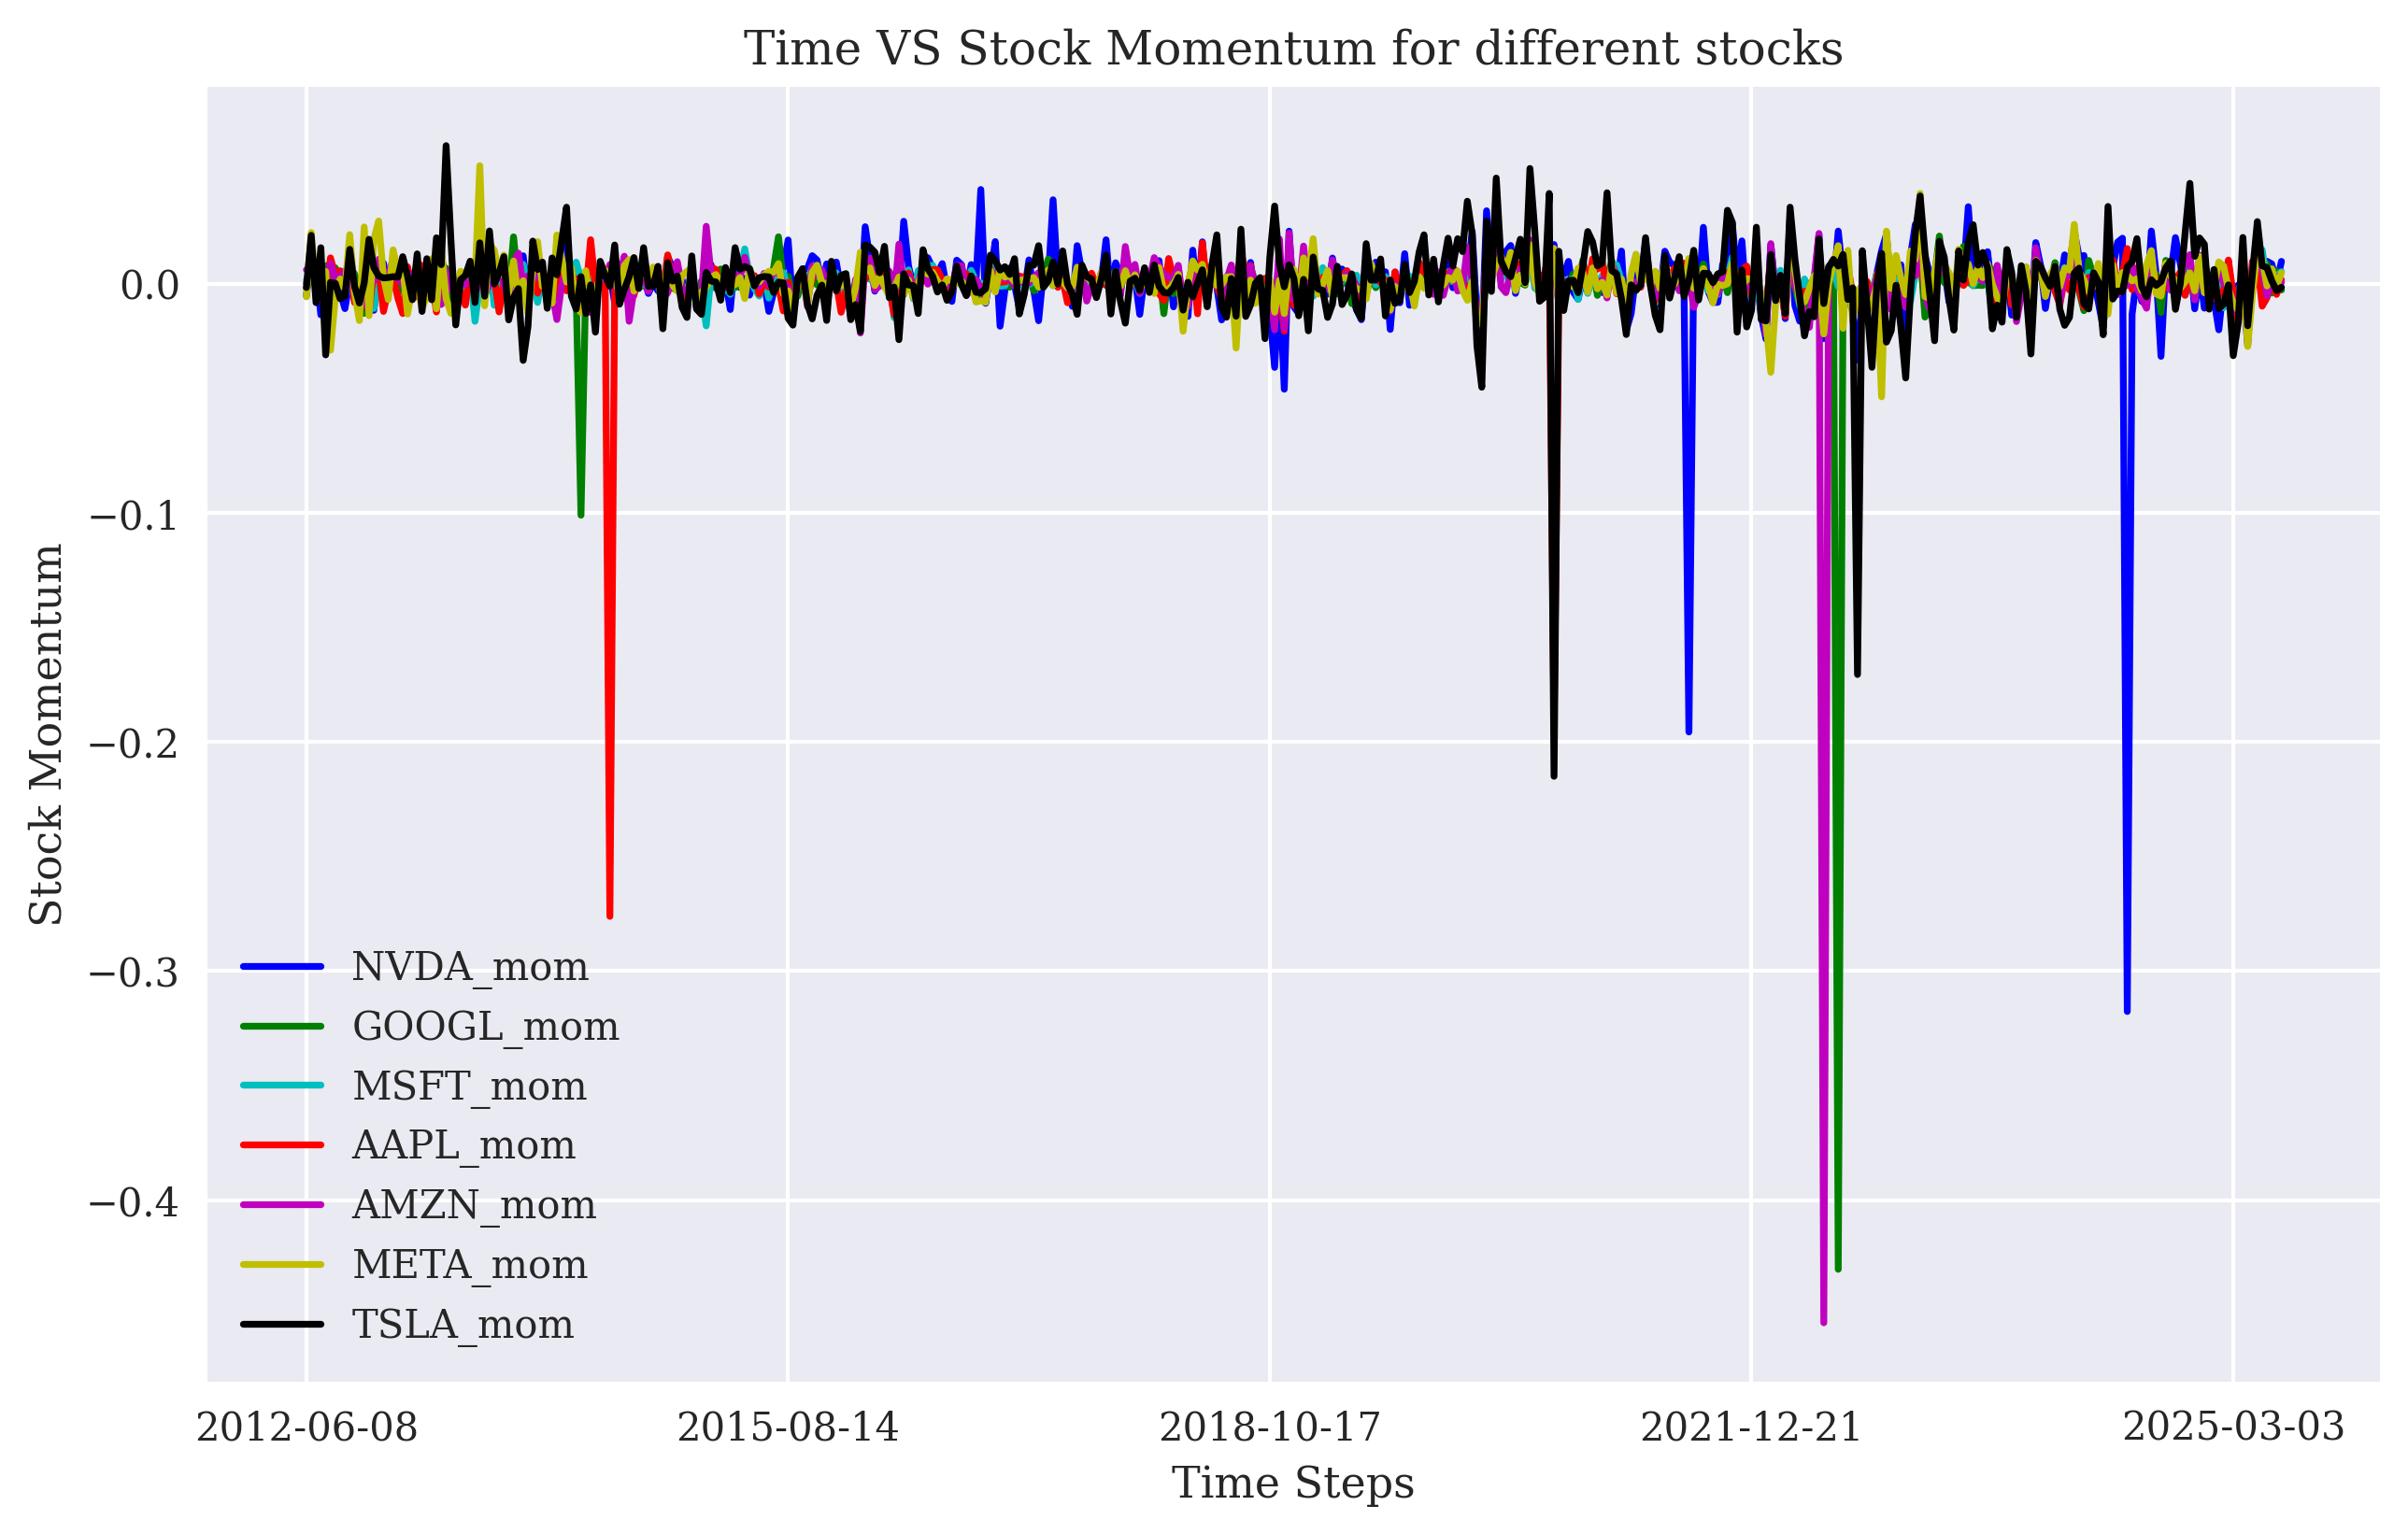

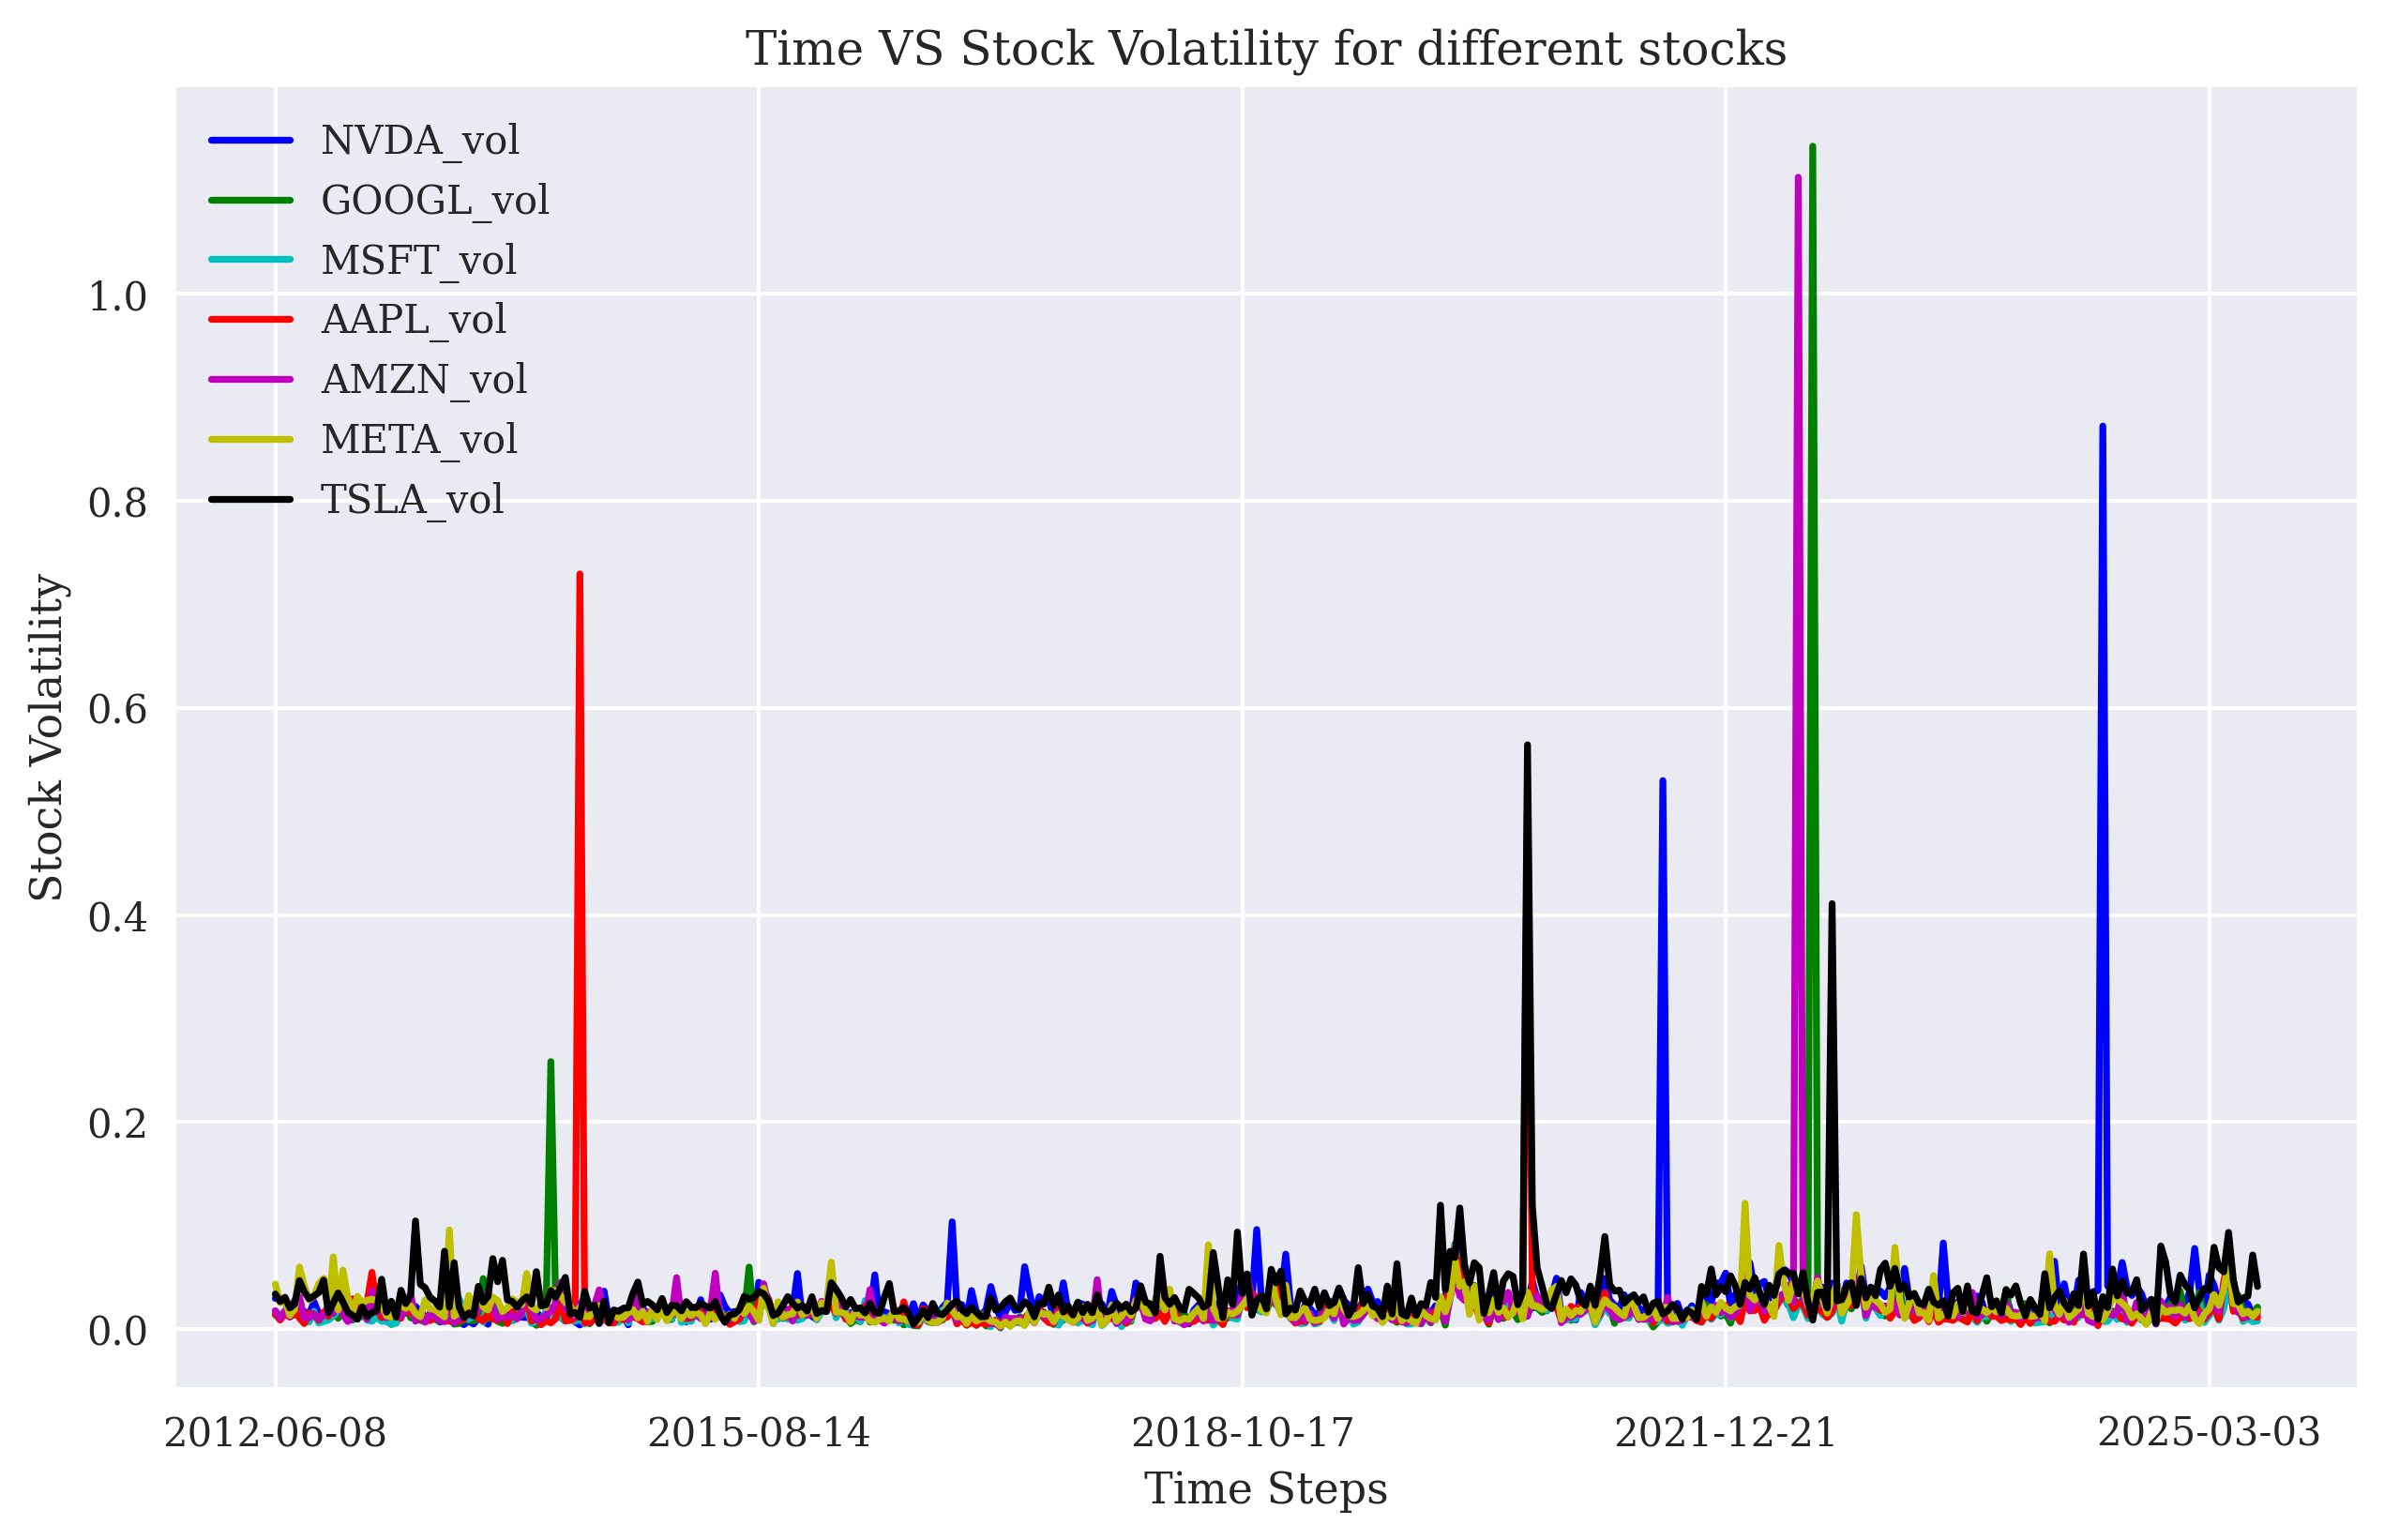

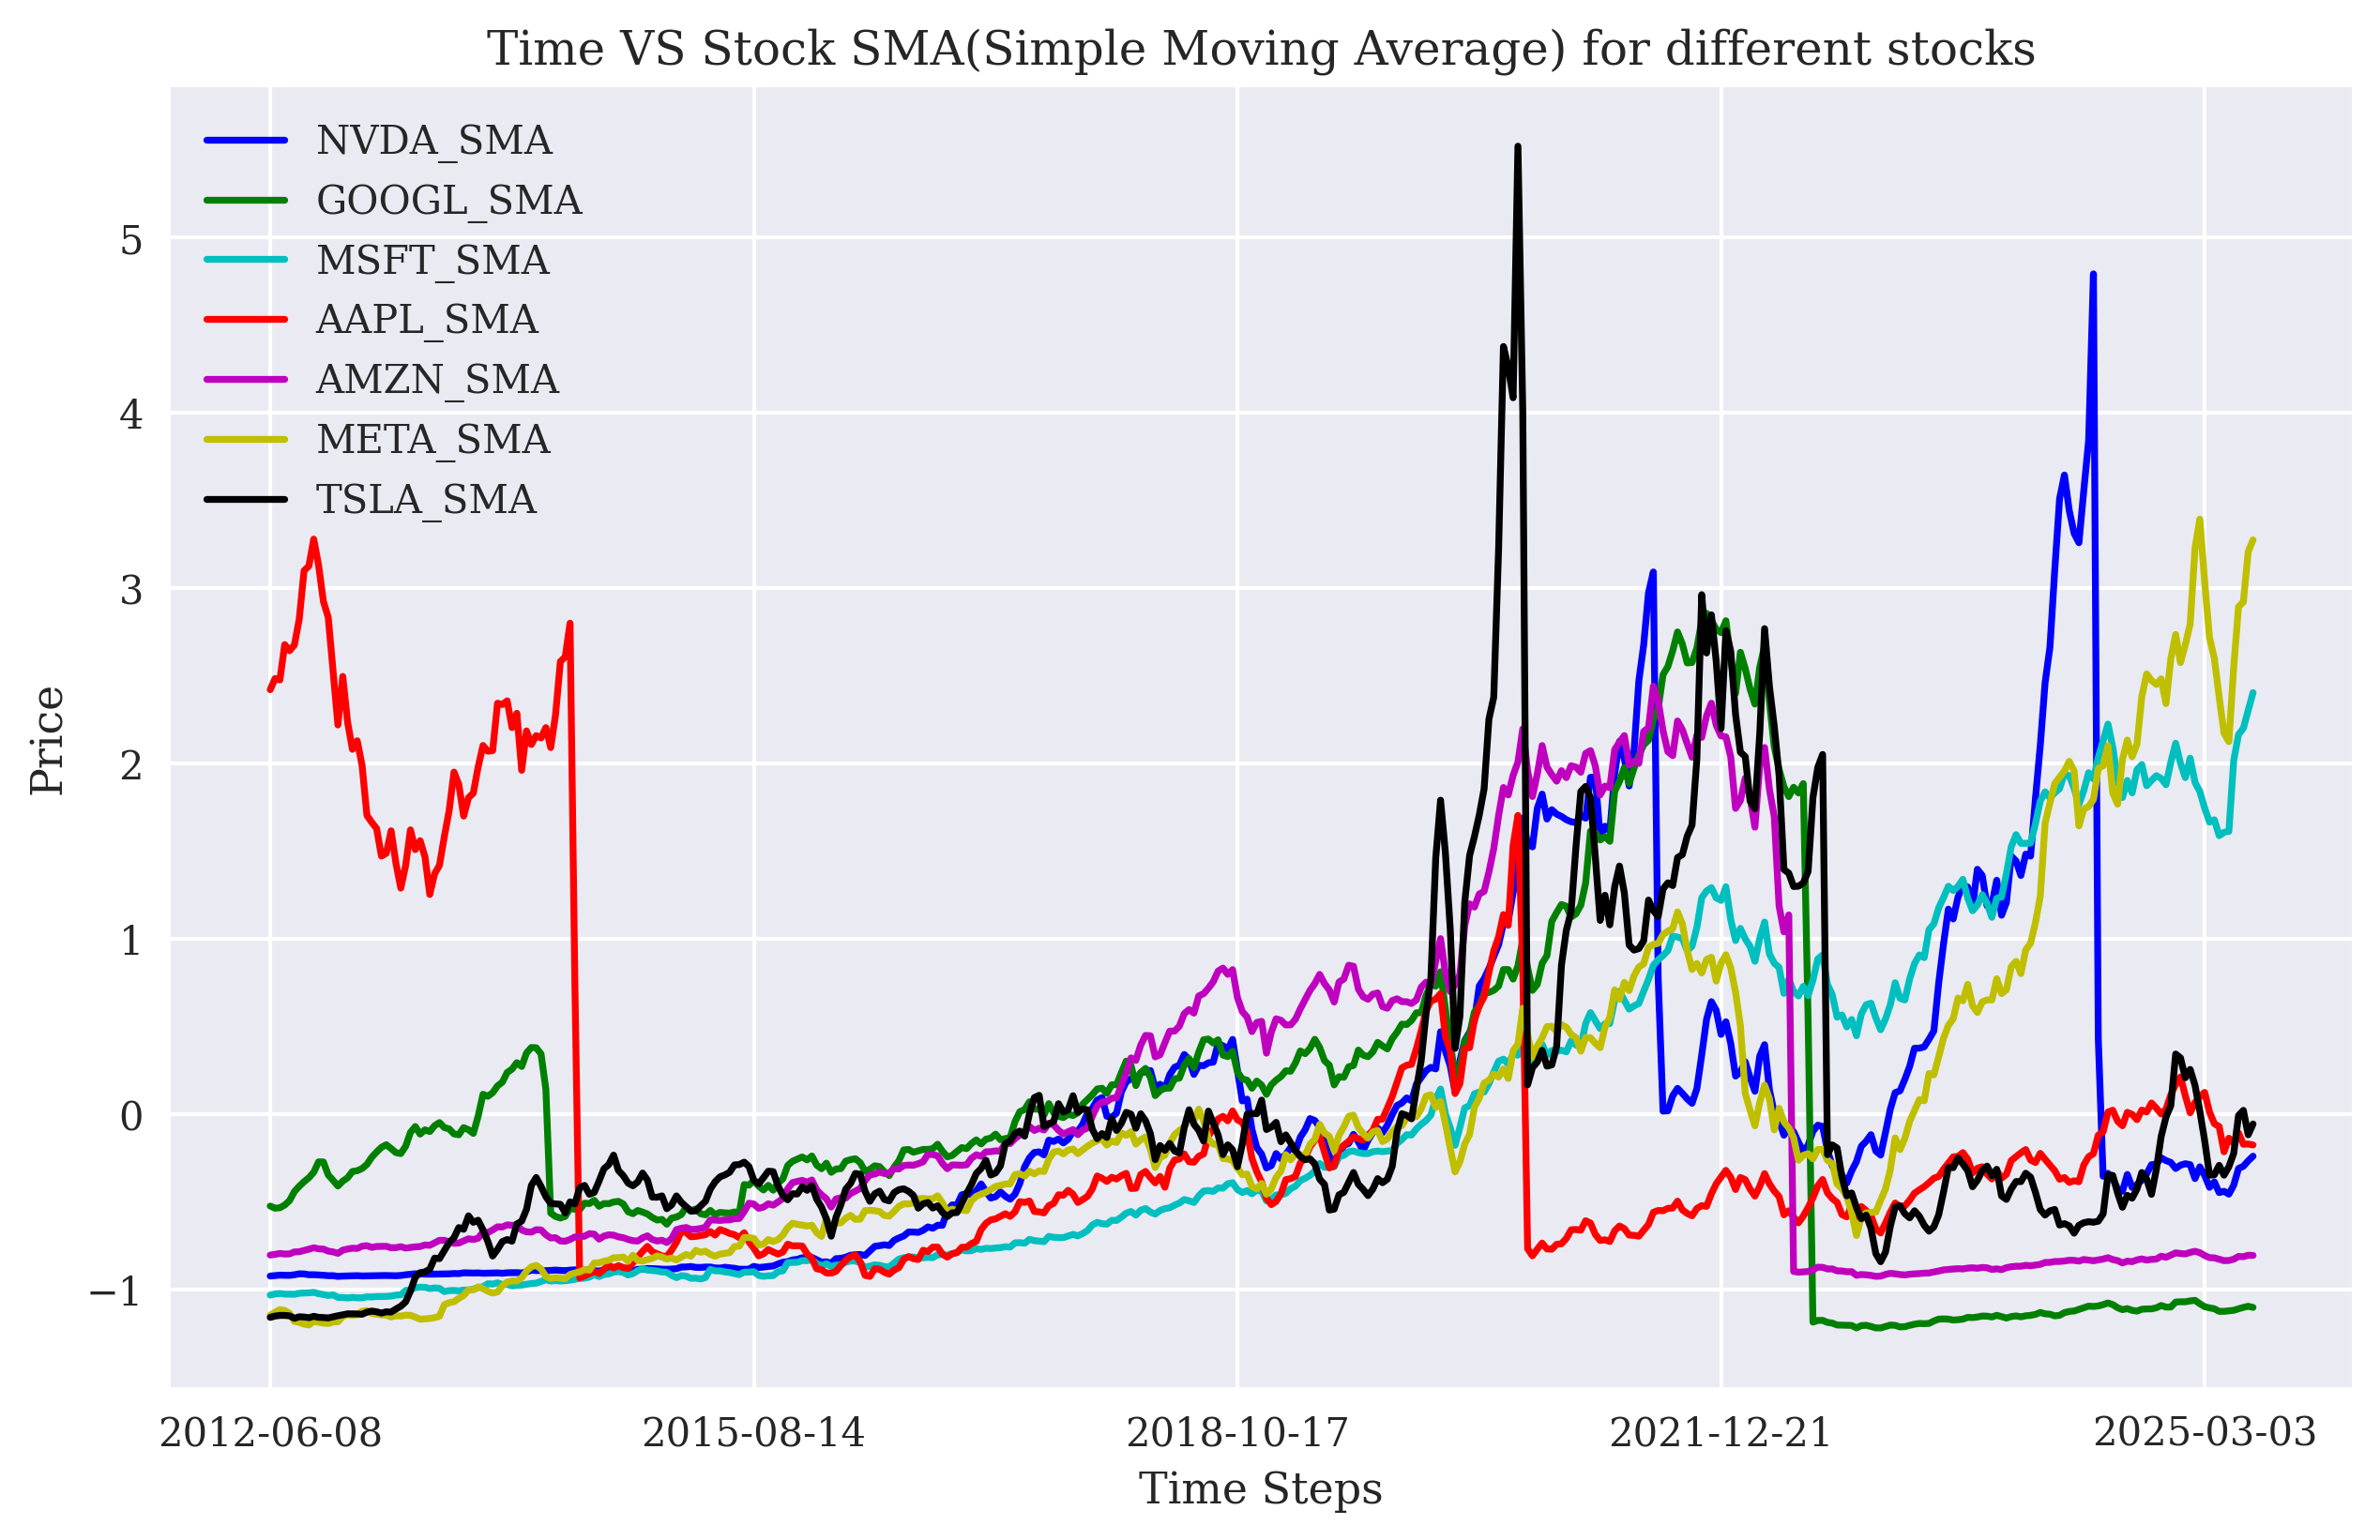

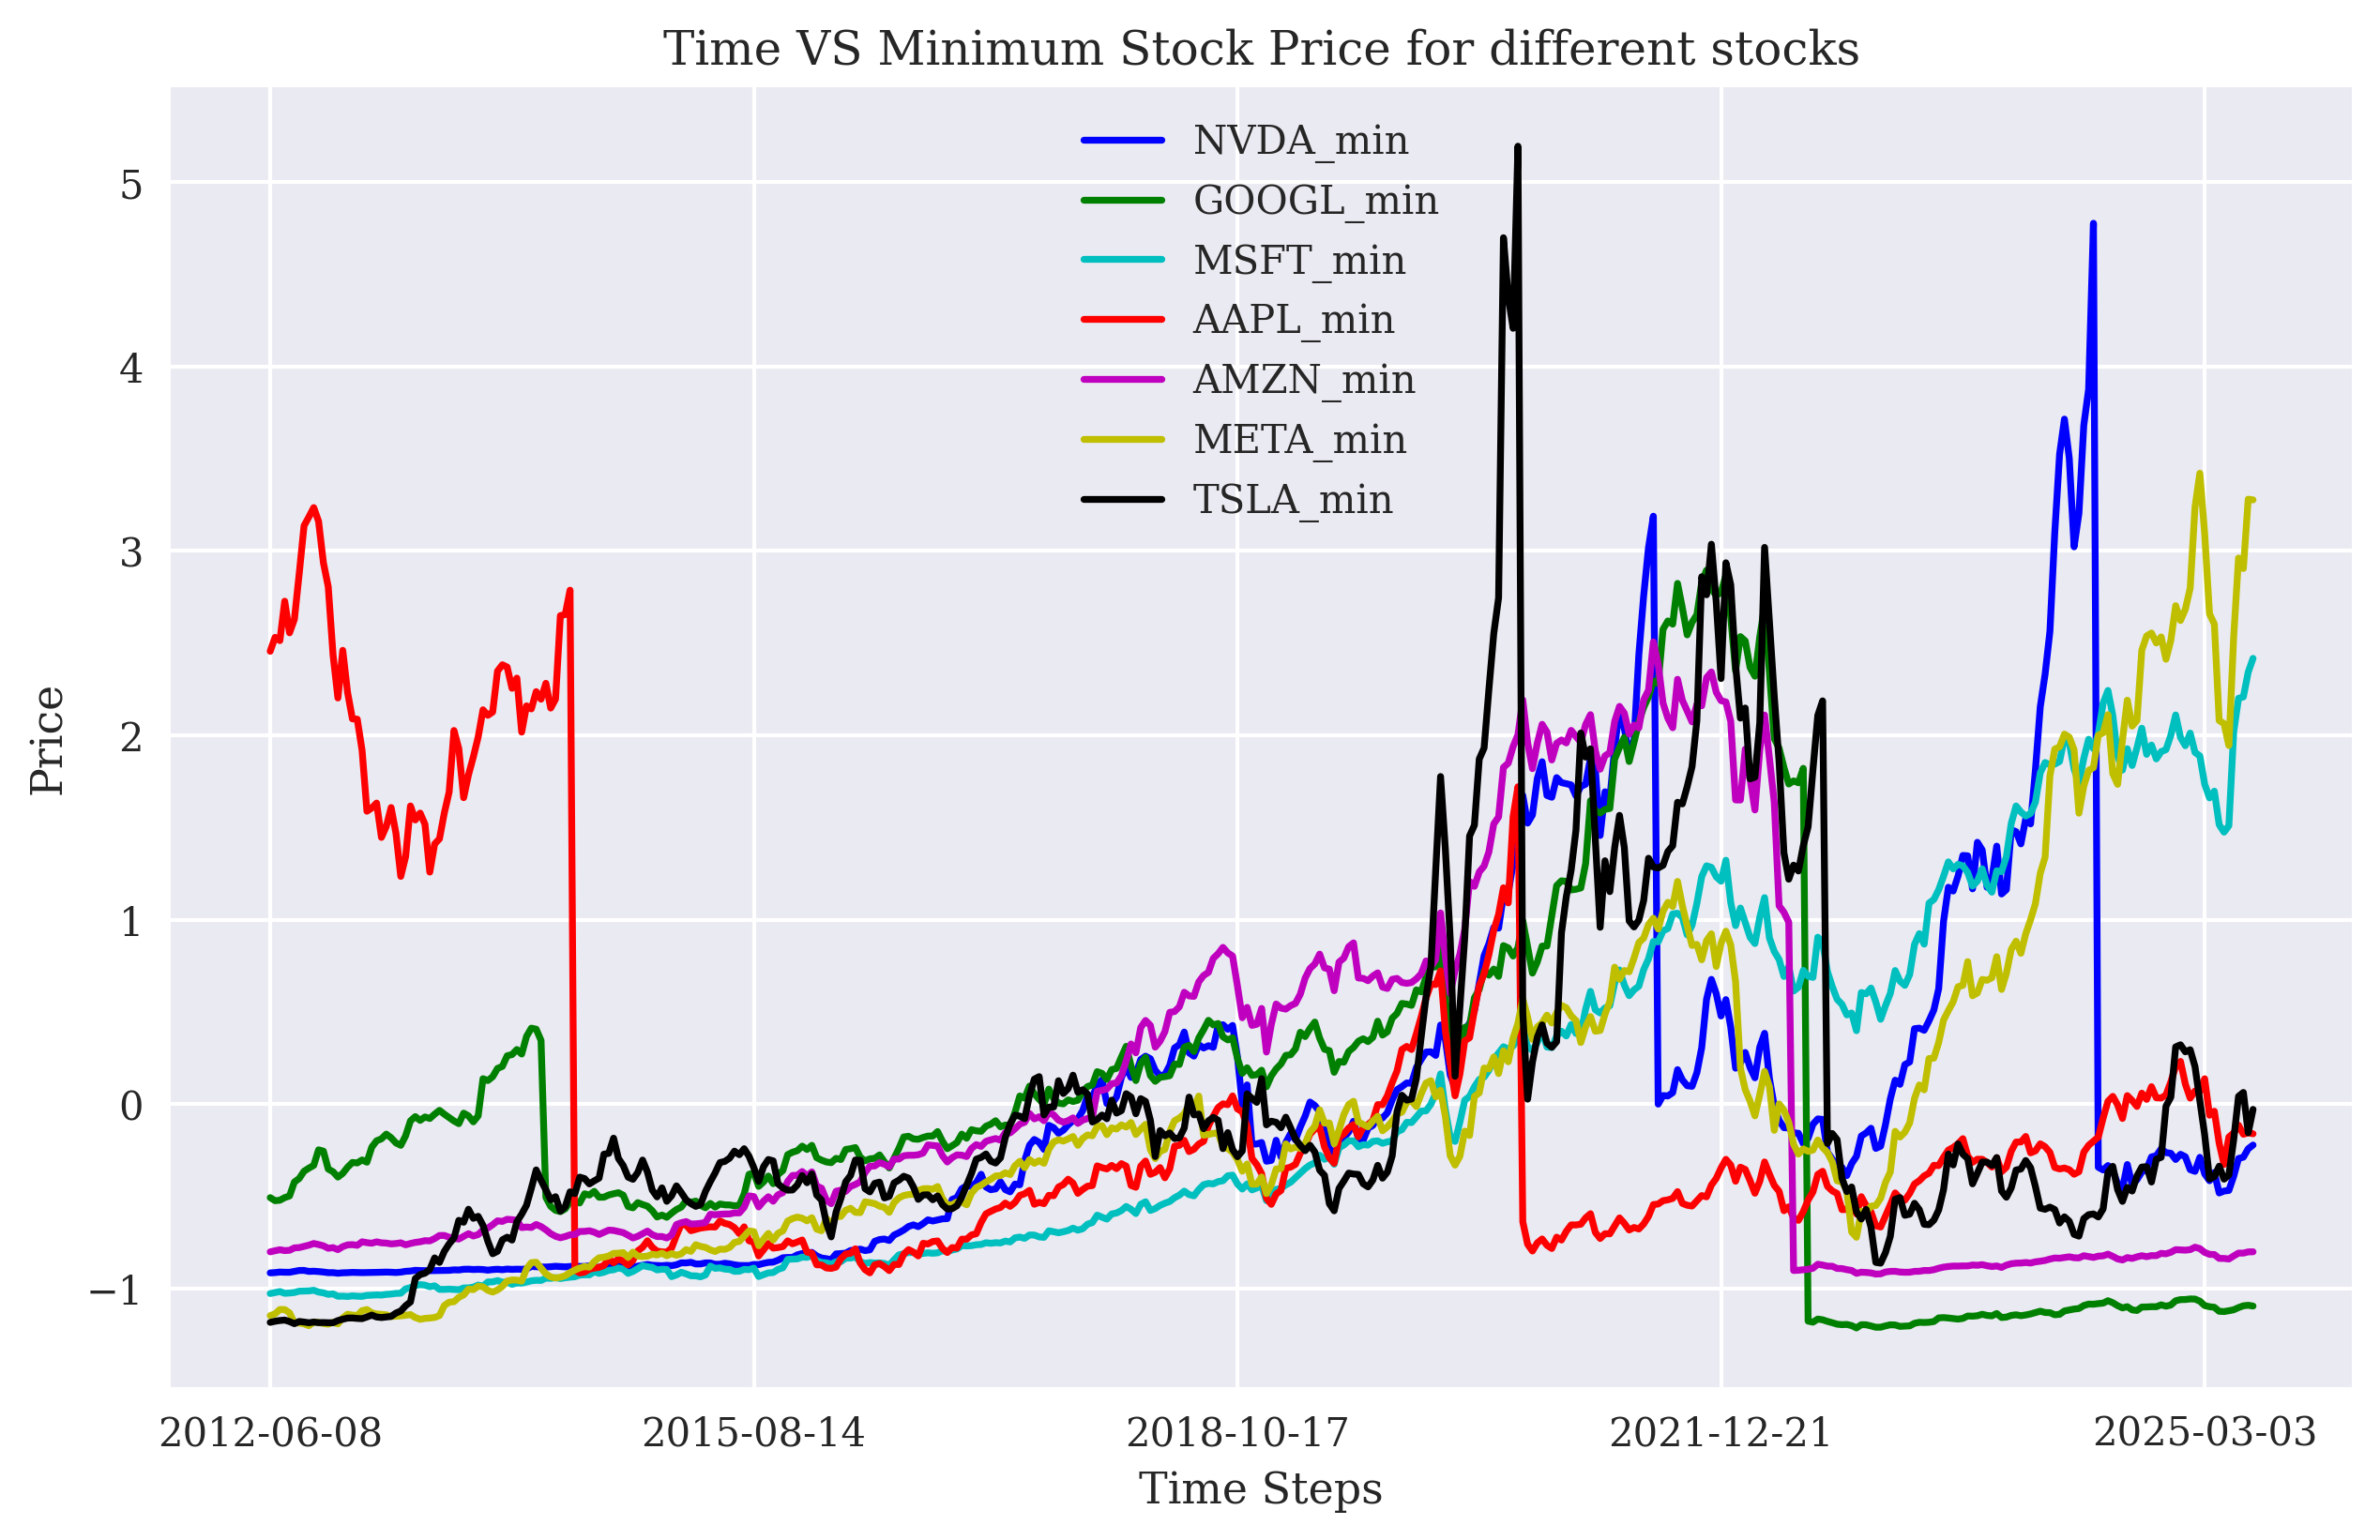

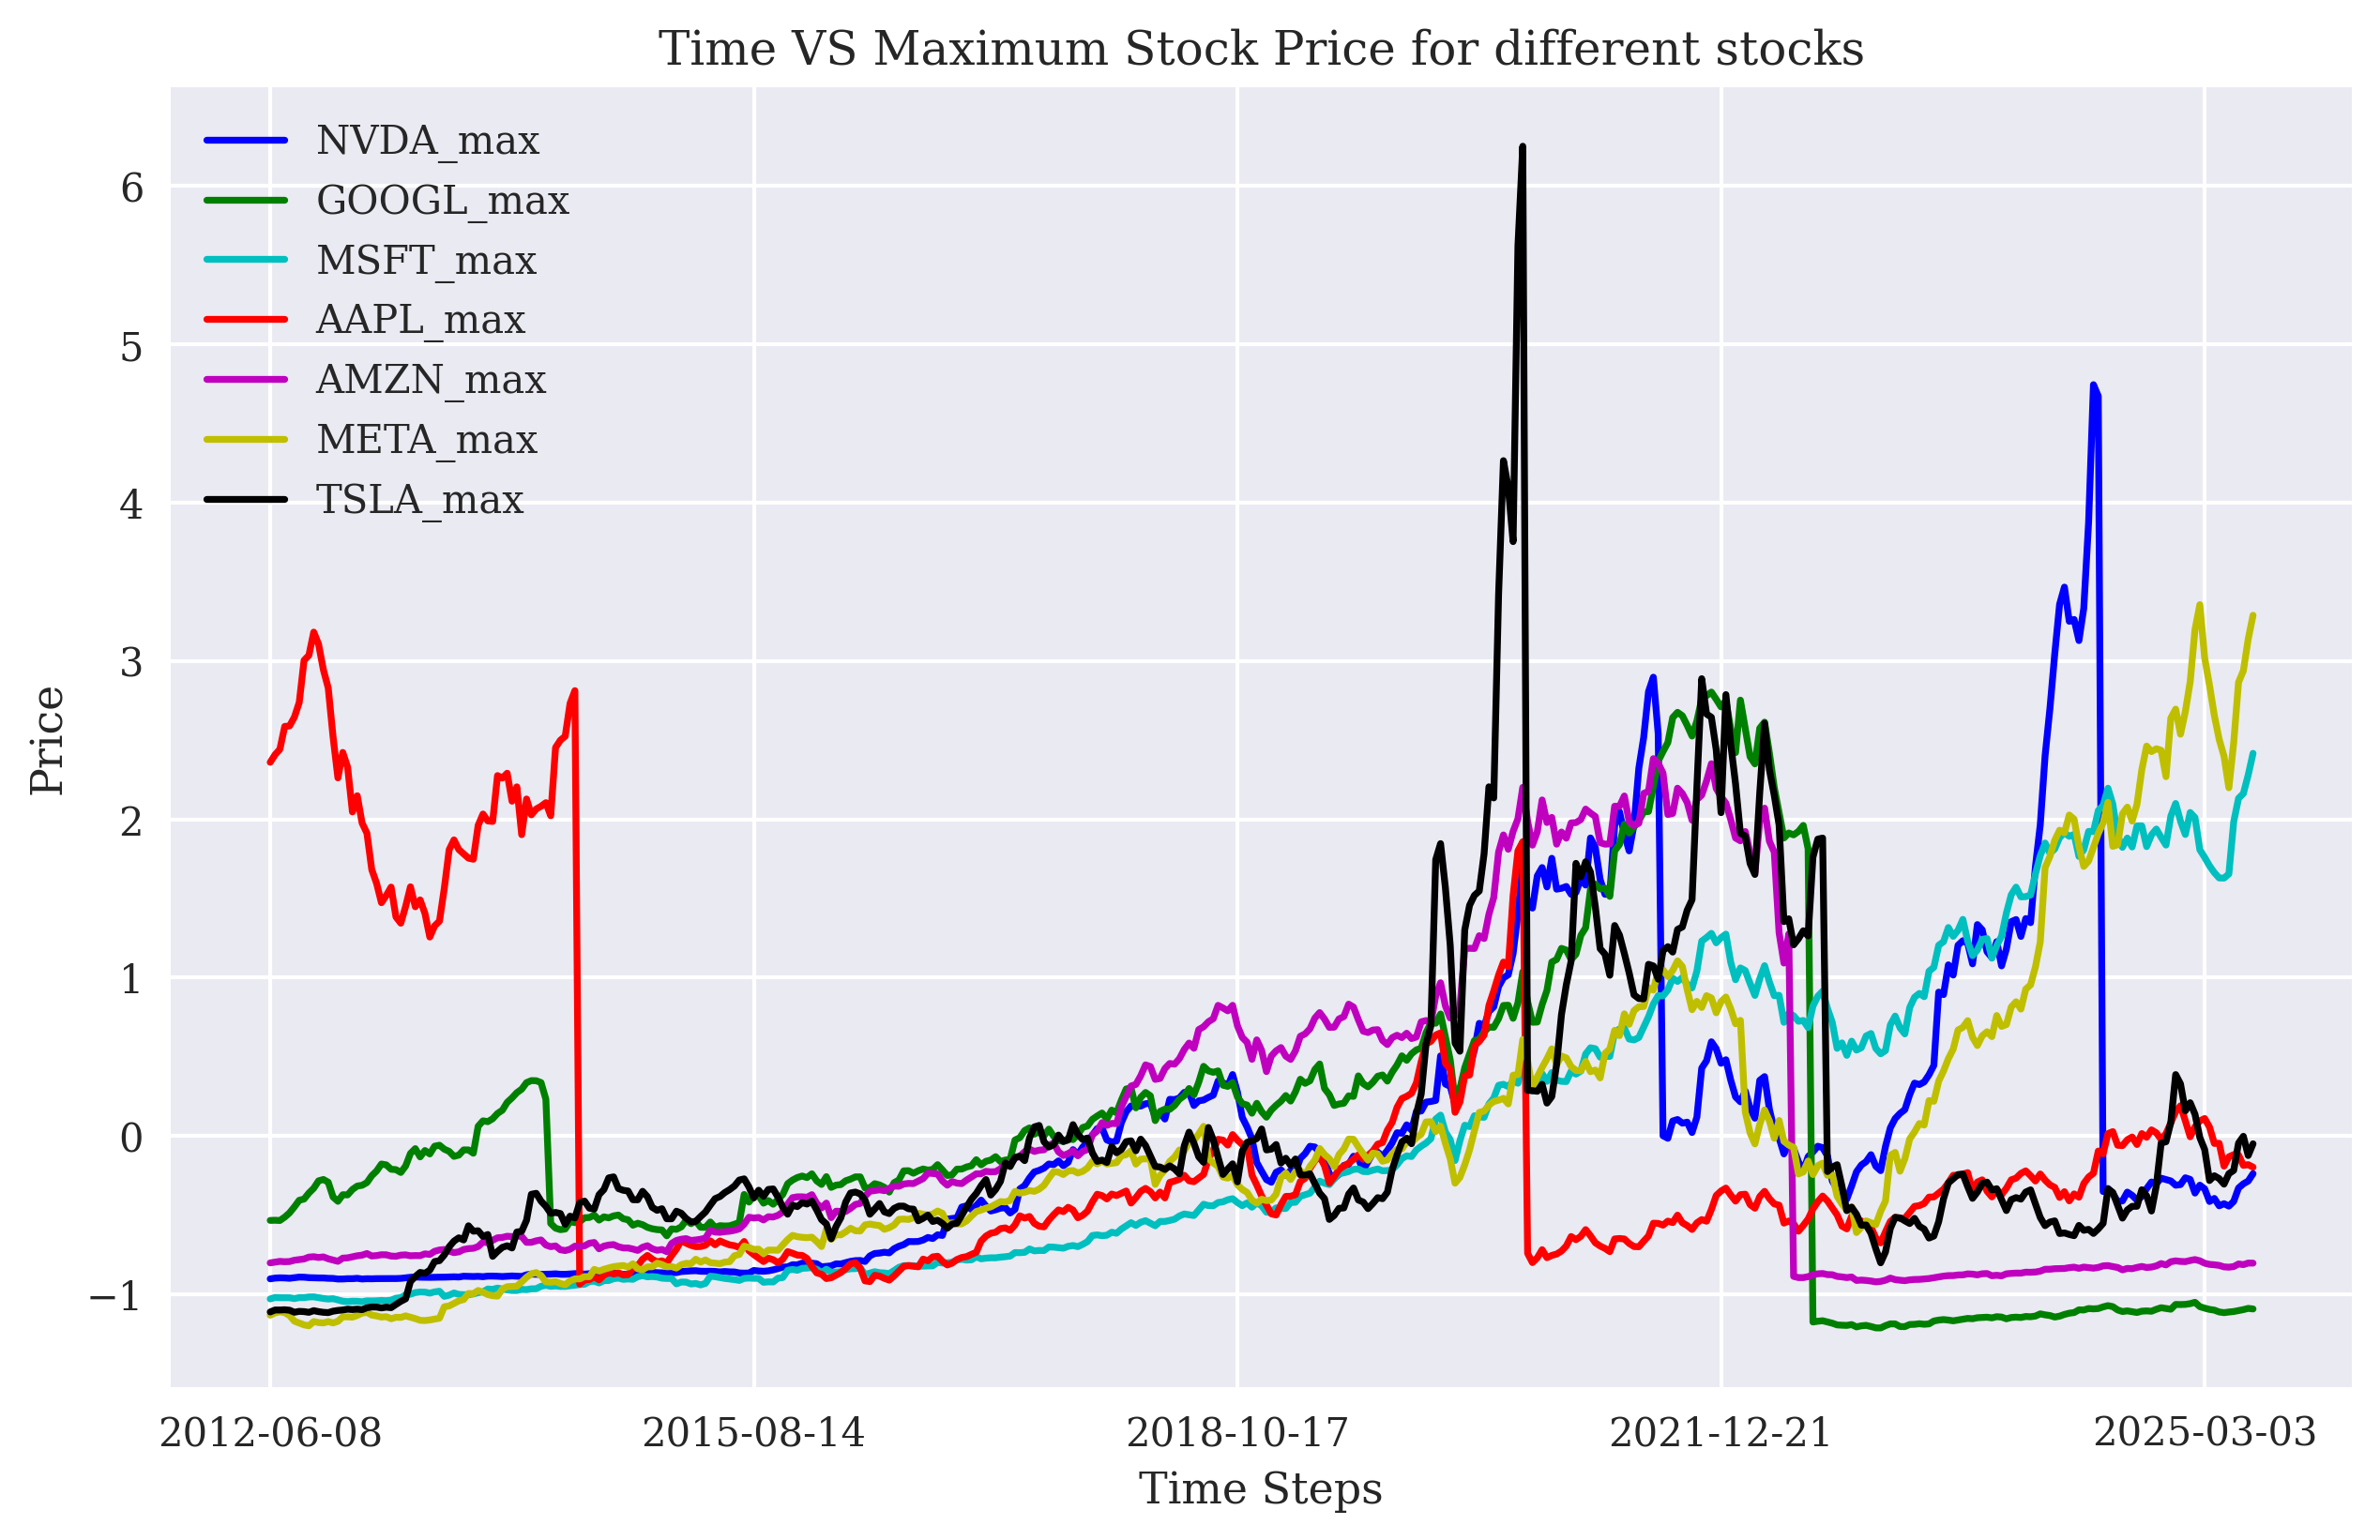

In [22]:
env.plots()

## Agent

### Model Config

#### Actor Model Config

In [23]:
actor_model_config={
    "LSTM":{
        "Models":{
            "Model_1":[
                {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_2":[
                    {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_3":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_4":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_5":[
                {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_6":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_7":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ]
            
        },
        "Input_Shape":{
            "Model_1":(7,7),
            "Model_2":(7,7),
            "Model_3":(7,7),
            "Model_4":(7,7),
            "Model_5":(7,7),
            "Model_6":(7,7),
            "Model_7":(7,7)
        
        }
    },
    "Dense":{
        "Models":
        {
            "Model_1":[
                {
                     "units":16,
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None         
                },
                 {
                     "units":32,
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None         
                }
                
            ]
        },
        "Input_Shape":{
            "Model_1":(7,)
        }
    },

    "Final_Model":[
        {
             "units":128,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":None        
        },
        {
             "units":64,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":l2(0.007)      
        },
        {
             "units":32,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":l2(0.009)      
        },
        {
             "units":16,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":None        
        },
        {
             "units":7,
             "activation":"sigmoid",
             "kernel_initializer":"glorot_uniform",
             "kernel_regularizer":None        
        }
        
    ]
   
}

#### Critic Model Config

In [24]:
critic_model_config={
    "LSTM":{
        "Models":{
            "Model_1":[
                {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_2":[
                    {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_3":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_4":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_5":[
                {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_6":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ],
            
            "Model_7":[
                 {
                     "units":16, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":True
                },
                {
                     "units":32, 
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None,
                     "return_sequences":False
                }
            ]
            
        },
        "Input_Shape":{
            "Model_1":(7,7),
            "Model_2":(7,7),
            "Model_3":(7,7),
            "Model_4":(7,7),
            "Model_5":(7,7),
            "Model_6":(7,7),
            "Model_7":(7,7)
        
        }
    },
    "Dense":{
        "Models":
        {
            "Model_1":[
                {
                     "units":16,
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None         
                },
                 {
                     "units":32,
                     "activation":"relu",
                     "kernel_initializer":"he_uniform",
                     "kernel_regularizer":None         
                }
                
            ]
        },
        "Input_Shape":{
            "Model_1":(7,)
        }
    },

    "Final_Model":[
        {
             "units":128,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":None        
        },
        {
             "units":64,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":l2(0.007)      
        },
        {
             "units":32,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":l2(0.009)      
        },
        {
             "units":8,
             "activation":"relu",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":None        
        },
        {
             "units":1,
             "activation":"linear",
             "kernel_initializer":"he_uniform",
             "kernel_regularizer":None        
        }
        
    ]
   
}

### Optimizer Config

#### Actor Optimizer Config

In [25]:
actor_optimizer_config={
    "learning_rate":0.00001,
    "beta_1":0.96,
    "beta_2":0.99,
    "clipnorm":1.0
}

#### Critic Optimizer Config

In [26]:
critic_optimizer_config={
    "learning_rate":0.00005,
    "beta_1":0.97,
    "beta_2":0.98,
    "clipnorm":1.0
}

### Agent Initialization

In [27]:
agent=Actor_Critic_Agent(
    env=env,
    actor_model_config=actor_model_config,
    critic_model_config=critic_model_config,
    actor_optimizer_config=actor_optimizer_config,
    critic_optimizer_config=critic_optimizer_config,
    actor_model_loss="binary_crossentropy",
    critic_model_loss="mse",
    batch_size=64,
    buffer_size=2000,
    exploration_episode=100,
    gamma=0.7,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.9975,
    model_trained=False
)

2025-07-02 19:54:24.992653: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Models

#### Actor Model

In [28]:
agent.get_model_architecture(agent.actor_model)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer[0][0] │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_1[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_2[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_3[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_4[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_5[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_6[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 7, 16)     │      1,536 │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 7, 16)     │      1,536 │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 99,550 (388.87 KB)

 Trainable params: 99,550 (388.87 KB)

 Non-trainable params: 0 (0.00 B)

#### Critic Model

In [29]:
agent.get_model_architecture(agent.critic_model)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_8[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_9[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_10[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_11[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_12[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_13[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 7, 7)      │         49 │ input_layer_14[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ (None, 7, 16)     │      1,536 │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_16 (LSTM)      │ (None, 7, 16)     │      1,536 │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 99,176 (387.41 KB)

 Trainable params: 99,176 (387.41 KB)

 Non-trainable params: 0 (0.00 B)

## Agent Training

In [30]:
agent.train_agent(episodes=1000,training_version="1_o")

Episode: 100/1000
Epsilon: 0.780508310365637
Total Reward: 0.5250532734221165
Average Reward Per Step: 0.0012775018818056362
Mean Squared Error between Real and Predicted State Value: 0.01532390787413415
***
Return Comparison: Varying Stocks Selected by StockPicker vs. Holding the Same Stock Throughout
Total Returns By (Stock Picker):0.33594702146620176
Total Returns By(AAPL|AMZN|META):0.9814569493167341
Total Returns By(MSFT|AMZN|AAPL):0.8901106365441586
Total Returns By (NVDA|AAPL|TSLA):1.6130412949495316
**********************************************************************************************************************************


Episode: 200/1000
Epsilon: 0.6076702394934471
Total Reward: 0.5230014465585304
Average Reward Per Step: 0.0012725096023321909
Mean Squared Error between Real and Predicted State Value: 0.002850013402995583
***
Return Comparison: Varying Stocks Selected by StockPicker vs. Holding the Same Stock Throughout
Total Returns By (Stock Picker):1.55120940959916

AttributeError: 'super' object has no attribute 'config'